# Vision Transformer с нуля на PyTorch

В этой работе нужно реализовать основные части Vision Transformer (ViT): разбиение изображения на патчи, patch embedding, positional embeddings, multi-head self-attention, transformer encoder block и итоговую модель классификации.

**Цель:** понять, как изображение превращается в последовательность токенов и как Transformer применяют к задаче классификации изображений.

## Правила

- Нельзя использовать готовую реализацию ViT из `timm`, `torchvision.models`, HuggingFace и подобных библиотек.
- Можно использовать PyTorch, torchvision datasets/transforms, matplotlib, numpy.
- В основных заданиях attention нужно реализовать вручную.


# 0. Установка и импорты

Если вы работаете в Google Colab, обычно достаточно установить только `torchvision`, если он не установлен.


In [1]:
import math
import random
from dataclasses import dataclass
from typing import Tuple, Optional, Dict, List

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split

try:
    import torchvision
    import torchvision.transforms as T
except Exception as e:
    torchvision = None
    T = None
    print("torchvision is not available:", e)


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print("DEVICE:", DEVICE)


DEVICE: cpu


# 1. Идея ViT

Обычная CNN обрабатывает изображение локальными свёртками. Vision Transformer делает иначе:

1. Делит изображение на маленькие квадратные патчи.
2. Каждый патч превращает в вектор — токен.
3. Добавляет positional embedding, чтобы модель знала порядок патчей.
4. Пропускает последовательность токенов через Transformer Encoder.
5. Использует специальный `[CLS]` токен для классификации.

Для изображения размера `H x W` и patch size `P` количество патчей:

$$N = 
{H}/{P} \cdot
{W}/{P}$$

Если изображение CIFAR10 имеет размер `32 x 32`, а patch size равен `4`, то получится `8 x 8 = 64` патча.

# Теоретический вопрос 1 

1. Зачем нужен токен CLS?
2. В чем идея деления пространства признаков на "головы внимания"?
3. На чем основывается выбор размера патча? 

## Ваш ответ: 
1) Токен CLS добавляется к последовательности патчей для агрегации глобальной информации со всего изображения. Так как слои self-attention заставляют токены взаимодействовать друг с другом, CLS-токен постепенно вбирает признаки всех остальных патчей. На выходе из Transformer Encoder мы берем только вектор этого токена и подаем его в линейный классификатор, чтобы получить итоговые метки классов.
2) Разные головы внимания позволяют модели одновременно фокусироваться на разных аспектах изображения. Например, одна голова может обращать внимание на текстуру, другая на цвет. Если бы голова была всего одна, модели было бы сложно улавливать все эти разные паттерны одновременно.
3) Выбор зависит от баланса между разрешением и вычислительной сложностью. Чем меньше патч, тем больше токенов N. Так как сложность self-attention квадратична от числа токенов, маленькие патчи сильно замедляют обучение и требуют больше памяти, но позволяют модели видеть более мелкие детали. Большие патчи работают быстрее, но теряют детали.

# 2. Разбиение изображения на патчи

Реализуйте функцию `image_to_patches`.

In [2]:
def image_to_patches(x: torch.Tensor, patch_size: int) -> torch.Tensor:
    """
    Convert batch of images into a batch of flattened patches.

    Args:
        x: Tensor of shape [B, C, H, W]
        patch_size: int, patch size P

    Returns:
        patches: Tensor of shape [B, N, C * P * P]
    """
    ############################################################################
        # TODO: Реализуйте разбиение изображения на патчи #
        # TODO: проверьте, что H и W делятся на patch_size
        # TODO: используйте unfold или reshape/permute
        # #
        ############################################################################
    
    B, C, H, W = x.shape
    assert H % patch_size == 0 and W % patch_size == 0, "H и W должны делиться на patch_size"
    
    num_patches_h = H // patch_size
    num_patches_w = W // patch_size
    
    x = x.reshape(B, C, num_patches_h, patch_size, num_patches_w, patch_size)
    x = x.permute(0, 2, 4, 1, 3, 5)
    
    num_patches = num_patches_h * num_patches_w
    patch_dim = C * patch_size * patch_size
    patches = x.reshape(B, num_patches, patch_dim)
    
    return patches
    
        ############################################################################
        #                             END OF YOUR CODE                             #
        ############################################################################
    

In [3]:
# Тесты для image_to_patches
x_test = torch.arange(2 * 3 * 8 * 8).float().reshape(2, 3, 8, 8)
patches = image_to_patches(x_test, patch_size=4)
assert patches.shape == (2, 4, 3 * 4 * 4), patches.shape
manual_first_patch = x_test[0, :, 0:4, 0:4].reshape(-1)
assert torch.equal(patches[0, 0], manual_first_patch)
print("image_to_patches tests passed")


image_to_patches tests passed


# 3. Patch Embedding

Далее патчи преобразуем в эмбеддинги длиной embed_dim в `PatchEmbedding`:

`[B, C, H, W] -> [B, N, embed_dim]`


In [4]:
class PatchEmbedding(nn.Module):
    def __init__(self, image_size: int, patch_size: int, in_channels: int, embed_dim: int):
        super().__init__()
        assert image_size % patch_size == 0, "image_size must be divisible by patch_size"
        self.image_size = image_size
        self.patch_size = patch_size
        self.in_channels = in_channels
        self.embed_dim = embed_dim
        self.num_patches = (image_size // patch_size) ** 2
        self.patch_dim = in_channels * patch_size * patch_size
        ############################################################################
        # TODO: создайте Linear слой для проекции patch_dim -> embed_dim
        
        ############################################################################
        
        self.proj = nn.Linear(self.patch_dim, self.embed_dim)
        
        ############################################################################
        #                             END OF YOUR CODE                             #
        ############################################################################
        
        

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        ############################################################################
        # TODO: получите patches через image_to_patches
        # TODO: примените self.proj
        ############################################################################
        
        patches = image_to_patches(x, self.patch_size)
        tokens = self.proj(patches)
        
        return tokens
        
        ############################################################################
        #                             END OF YOUR CODE                             #
        ############################################################################
        

In [5]:
# Тесты для PatchEmbedding
patch_embed = PatchEmbedding(image_size=32, patch_size=4, in_channels=3, embed_dim=64)
x = torch.randn(5, 3, 32, 32)
out = patch_embed(x)
assert out.shape == (5, 64, 64), out.shape
assert patch_embed.num_patches == 64
print("PatchEmbedding tests passed")


PatchEmbedding tests passed


# 4. Positional Embeddings и CLS token

Transformer сам по себе не знает порядок токенов. Поэтому к токенам добавляют positional embeddings.

Для классификации часто добавляют специальный `[CLS]` токен. После Transformer Encoder берут именно его выход и подают в классификатор.

Реализуйте класс `TokenPreparation`:

```python
patch_tokens: [B, N, D]
output:       [B, N + 1, D]
```


In [6]:
class TokenPreparation(nn.Module):
    def __init__(self, num_patches: int, embed_dim: int):
        super().__init__()
        self.num_patches = num_patches
        self.embed_dim = embed_dim
        ############################################################################
        # TODO: создайте learnable cls_token формы [1, 1, D]
        # TODO: создайте learnable pos_embed формы [1, N + 1, D]
        ############################################################################
        
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))

        ############################################################################
        #                             END OF YOUR CODE                             #
        ############################################################################
        

    def forward(self, patch_tokens: torch.Tensor) -> torch.Tensor:
        ############################################################################
        # TODO: расширьте cls_token под batch size
        # TODO: соедините cls_token и patch_tokens по dimension=1
        # TODO: добавьте positional embedding
        ############################################################################
        
        B = patch_tokens.shape[0]
        
        cls_tokens = self.cls_token.expand(B, -1, -1)
        
        x = torch.cat((cls_tokens, patch_tokens), dim=1)
        x = x + self.pos_embed
        
        return x
        
        ############################################################################
        #                             END OF YOUR CODE                             #
        ############################################################################
            

In [7]:
# Тесты для TokenPreparation
prep = TokenPreparation(num_patches=64, embed_dim=128)
tokens = torch.randn(2, 64, 128)
out = prep(tokens)
assert out.shape == (2, 65, 128), out.shape
assert isinstance(prep.cls_token, nn.Parameter)
assert isinstance(prep.pos_embed, nn.Parameter)
print("TokenPreparation tests passed")


TokenPreparation tests passed


# 5. Scaled Dot-Product Attention

Реализуйте attention:

$$Attention(Q, K, V) = softmax(
{QK^T}/{\sqrt{d_k}}
)V$$

Вход: `q, k, v: [B, heads, N, head_dim]`

Выход:

- `out: [B, heads, N, head_dim]`
- `attn: [B, heads, N, N]`


In [8]:
def scaled_dot_product_attention(
    q: torch.Tensor,
    k: torch.Tensor,
    v: torch.Tensor,
    dropout: Optional[nn.Module] = None,
) -> Tuple[torch.Tensor, torch.Tensor]:
    ############################################################################
    # TODO: scores = q @ k.transpose(-2, -1)
    # TODO: scores / sqrt(head_dim)
    # TODO: softmax по последней размерности
    # TODO: dropout, если задан
    # TODO: out = attn @ v
    ############################################################################
    head_dim = q.shape[-1]
    
    scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(head_dim)
    attn = F.softmax(scores, dim=-1)
    
    if dropout is not None:
        attn = dropout(attn)
        
    out = torch.matmul(attn, v)
    
    return out, attn
    
    ############################################################################
    #                             END OF YOUR CODE                             #
    ############################################################################
        

In [9]:
# Тесты для scaled_dot_product_attention
q = torch.randn(2, 4, 10, 16)
k = torch.randn(2, 4, 10, 16)
v = torch.randn(2, 4, 10, 16)
out, attn = scaled_dot_product_attention(q, k, v)
assert out.shape == (2, 4, 10, 16)
assert attn.shape == (2, 4, 10, 10)
assert torch.allclose(attn.sum(dim=-1), torch.ones_like(attn.sum(dim=-1)), atol=1e-5)
print("scaled_dot_product_attention tests passed")


scaled_dot_product_attention tests passed


# 6. Multi-Head Self-Attention

Реализуйте `MultiHeadSelfAttention`.

Внутри нужно:

1. Получить `qkv` одной линейной проекцией или тремя отдельными.
2. Разделить embedding dimension на `num_heads` голов.
3. Применить scaled dot-product attention.
4. Склеить головы обратно.
5. Применить финальную линейную проекцию.


In [10]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim: int, num_heads: int, attn_dropout: float = 0.0, proj_dropout: float = 0.0):
        super().__init__()
        assert embed_dim % num_heads == 0, "embed_dim must be divisible by num_heads"
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        ############################################################################
        # TODO: создайте qkv projection: D -> 3D
        # TODO: создайте output projection: D -> D
        ############################################################################
        
        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        self.proj = nn.Linear(embed_dim, embed_dim)
        
        self.attn_drop = nn.Dropout(attn_dropout)
        self.proj_drop = nn.Dropout(proj_dropout)
        self.last_attention: Optional[torch.Tensor] = None
        
        ############################################################################
        #                             END OF YOUR CODE                             #
        ############################################################################
        
        

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        ############################################################################
        # TODO: qkv = self.qkv(x)
        # TODO: reshape/permute к [B, heads, N, head_dim]
        # TODO: вызовите scaled_dot_product_attention
        # TODO: сохраните attention weights в self.last_attention
        # TODO: склейте головы и примените финальную проекцию
        ############################################################################
        
        B, N, D = x.shape
        
        qkv = self.qkv(x) 
        qkv = qkv.reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4) 
        
        q, k, v = qkv[0], qkv[1], qkv[2] 
        
        out, attn = scaled_dot_product_attention(q, k, v, self.attn_drop)
        self.last_attention = attn
        
        out = out.transpose(1, 2).reshape(B, N, D)
        
        out = self.proj(out)
        out = self.proj_drop(out)
        
        return out
        
        ############################################################################
        #                             END OF YOUR CODE                             #
        ############################################################################
        
        

In [11]:
# Тесты для MultiHeadSelfAttention
mha = MultiHeadSelfAttention(embed_dim=128, num_heads=8)
x = torch.randn(3, 65, 128)
y = mha(x)
assert y.shape == x.shape
assert mha.last_attention is not None
assert mha.last_attention.shape == (3, 8, 65, 65)
print("MultiHeadSelfAttention tests passed")


MultiHeadSelfAttention tests passed


# 7. MLP block

В Transformer Encoder после attention идёт feed-forward network:

`Linear(D, hidden_dim) -> GELU -> Dropout -> Linear(hidden_dim, D) -> Dropout`


In [12]:
class MLP(nn.Module):
    def __init__(self, embed_dim: int, mlp_ratio: float = 4.0, dropout: float = 0.0):
        super().__init__()
        hidden_dim = int(embed_dim * mlp_ratio)
        ############################################################################
        # TODO: реализуйте MLP через nn.Sequential
        ############################################################################

        self.net = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, embed_dim),
            nn.Dropout(dropout)
        )
        
        ############################################################################
        #                             END OF YOUR CODE                             #
        ############################################################################
        

        

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

In [13]:
# Тесты для MLP
mlp = MLP(embed_dim=128, mlp_ratio=4.0, dropout=0.1)
x = torch.randn(2, 65, 128)
y = mlp(x)
assert y.shape == x.shape
print("MLP tests passed")


MLP tests passed


# 8. Transformer Encoder Block

Реализуйте Pre-LN блок:

```text
x = x + Attention(LayerNorm(x))
x = x + MLP(LayerNorm(x))
```


In [14]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim: int, num_heads: int, mlp_ratio: float = 4.0, dropout: float = 0.0, attn_dropout: float = 0.0):
        super().__init__()
        ############################################################################
        ## TODO: создайте norm1, attn, norm2, mlp
        ############################################################################
        
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadSelfAttention(embed_dim, num_heads, attn_dropout, dropout)
        
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = MLP(embed_dim, mlp_ratio, dropout)
        
        ############################################################################
        #                             END OF YOUR CODE                             #
        ############################################################################
        
        

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        ############################################################################
        # TODO: residual connection around attention
        # TODO: residual connection around MLP
        ############################################################################
        
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        
        return x
        
        ############################################################################
        #                             END OF YOUR CODE                             #
        ############################################################################
        
        


In [15]:
# Тесты для TransformerEncoderBlock
block = TransformerEncoderBlock(embed_dim=128, num_heads=8, dropout=0.1, attn_dropout=0.1)
x = torch.randn(2, 65, 128)
y = block(x)
assert y.shape == x.shape
print("TransformerEncoderBlock tests passed")


TransformerEncoderBlock tests passed


# 9. Полная модель Vision Transformer

Соберите полный ViT:

1. PatchEmbedding
2. TokenPreparation
3. Несколько TransformerEncoderBlock
4. LayerNorm
5. Classification head


In [16]:
@dataclass
class ViTConfig:
    image_size: int = 32
    patch_size: int = 4
    in_channels: int = 3
    num_classes: int = 10
    embed_dim: int = 128
    depth: int = 4
    num_heads: int = 8
    mlp_ratio: float = 4.0
    dropout: float = 0.1
    attn_dropout: float = 0.1


class VisionTransformer(nn.Module):
    def __init__(self, config: ViTConfig):
        super().__init__()
        self.config = config
        ############################################################################
        # TODO: создайте PatchEmbedding
        # TODO: создайте TokenPreparation
        # TODO: создайте список TransformerEncoderBlock
        # TODO: создайте norm и head
        ############################################################################
        
        self.config = config
        
        self.patch_embed = PatchEmbedding(config.image_size, config.patch_size, config.in_channels, config.embed_dim)
        self.token_prep = TokenPreparation(self.patch_embed.num_patches, config.embed_dim)
        self.dropout = nn.Dropout(config.dropout)
        
        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(
                config.embed_dim, config.num_heads, config.mlp_ratio, 
                config.dropout, config.attn_dropout
            ) for _ in range(config.depth)
        ])
        
        self.norm = nn.LayerNorm(config.embed_dim)
        self.head = nn.Linear(config.embed_dim, config.num_classes)
 
        ############################################################################
        #                             END OF YOUR CODE                             #
        ############################################################################
    # def _init_weights(self, module):
    #     if isinstance(module, nn.Linear):
    #         nn.init.trunc_normal_(module.weight, std=0.02)
    #         if module.bias is not None:
    #             nn.init.zeros_(module.bias)
    #     elif isinstance(module, nn.LayerNorm):
    #         nn.init.ones_(module.weight)
    #         nn.init.zeros_(module.bias)
    # def forward_features(self, x: torch.Tensor) -> torch.Tensor:
    #     x = self.patch_embed(x)
    #     x = self.token_prep(x)
    #     x = self.dropout(x)
    #     for block in self.blocks:
    #         x = block(x)
    #     x = self.norm(x)
    #     cls_token = x[:, 0]
    #     return cls_token
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        ############################################################################
        # TODO: patch embedding
        # TODO: add cls token and pos embeddings
        # TODO: transformer blocks
        # TODO: final norm
        # TODO: take cls token
        # TODO: classification head
        ############################################################################
        
        x = self.patch_embed(x)
        x = self.token_prep(x)
        x = self.dropout(x)
        
        for block in self.blocks:
            x = block(x)
            
        x = self.norm(x)
        
        cls_token = x[:, 0]
        
        logits = self.head(cls_token)
        
        return logits
    
        ############################################################################
        #                             END OF YOUR CODE                             #
        ############################################################################


In [17]:
# Тесты для VisionTransformer
config = ViTConfig(image_size=32, patch_size=4, embed_dim=128, depth=2, num_heads=8, num_classes=10)
model = VisionTransformer(config)
x = torch.randn(4, 3, 32, 32)
logits = model(x)
assert logits.shape == (4, 10), logits.shape
print("VisionTransformer tests passed")


VisionTransformer tests passed


# 10. Данные CIFAR10

In [18]:
def get_cifar10_loaders(batch_size: int = 128, val_size: int = 5000):
    assert torchvision is not None, "torchvision is required for CIFAR10"
    train_transform = T.Compose([
        T.RandomCrop(32, padding=4),
        T.RandomHorizontalFlip(),
        T.ToTensor(),
        T.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
    ])
    test_transform = T.Compose([
        T.ToTensor(),
        T.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
    ])
    full_train = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=train_transform)
    test_set = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=test_transform)
    train_size = len(full_train) - val_size
    train_set, val_set = random_split(full_train, [train_size, val_size])
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    return train_loader, val_loader, test_loader


# 11. Training loop

Реализуйте функции `train_one_epoch` и `evaluate`.

Требования:

- использовать `model.train()` при обучении;
- использовать `model.eval()` при оценке;
- считать средний loss;
- считать accuracy.


In [25]:
def accuracy_from_logits(logits: torch.Tensor, y: torch.Tensor) -> float:
    pred = logits.argmax(dim=1)
    return (pred == y).float().mean().item()


def train_one_epoch(model, loader, optimizer, criterion, device: str) -> Dict[str, float]:
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_count = 0
    
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        batch_size = x.shape[0]
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_count += batch_size
        
    return {"loss": total_loss / total_count, "acc": total_correct / total_count}
    

@torch.no_grad()
def evaluate(model, loader, criterion, device: str) -> Dict[str, float]:
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_count = 0
    
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        
        logits = model(x)
        loss = criterion(logits, y)
        
        batch_size = x.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_count += batch_size
        
    return {"loss": total_loss / total_count, "acc": total_correct / total_count}


In [20]:
# Быстрая проверка training loop на случайных данных
class RandomImageDataset(torch.utils.data.Dataset):
    def __init__(self, n=128, num_classes=10):
        self.x = torch.randn(n, 3, 32, 32)
        self.y = torch.randint(0, num_classes, (n,))
    def __len__(self):
        return len(self.x)
    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

random_loader = DataLoader(RandomImageDataset(n=64), batch_size=16, shuffle=True)
model = VisionTransformer(ViTConfig(depth=1, embed_dim=64, num_heads=4)).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.05)
criterion = nn.CrossEntropyLoss()
train_metrics = train_one_epoch(model, random_loader, optimizer, criterion, DEVICE)
val_metrics = evaluate(model, random_loader, criterion, DEVICE)
assert "loss" in train_metrics and "acc" in train_metrics
assert "loss" in val_metrics and "acc" in val_metrics
print("training loop tests passed", train_metrics, val_metrics)


training loop tests passed {'loss': 2.46762478351593, 'acc': 0.0625} {'loss': 2.184887647628784, 'acc': 0.203125}


# 12. Запуск обучения

Рекомендуемые параметры для первого запуска:

```python
ViTConfig(image_size=32, patch_size=4, embed_dim=128, depth=4, num_heads=8)
```

Для быстрой проверки можно поставить `depth=2`, `embed_dim=64`, `num_heads=4`.

### Validation acc > 0.6 => 100% score


In [21]:
# Раскомментируйте для обучения на CIFAR10

train_loader, val_loader, test_loader = get_cifar10_loaders(batch_size=128)
config = ViTConfig(image_size=32, patch_size=4, embed_dim=128, depth=4, num_heads=8)
model = VisionTransformer(config).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.05)
criterion = nn.CrossEntropyLoss()
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
epochs = 10
for epoch in range(1, epochs + 1):
    train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_metrics = evaluate(model, val_loader, criterion, DEVICE)
    history["train_loss"].append(train_metrics["loss"])
    history["train_acc"].append(train_metrics["acc"])
    history["val_loss"].append(val_metrics["loss"])
    history["val_acc"].append(val_metrics["acc"])
    print(f"Epoch {epoch:02d}: train loss={train_metrics['loss']:.4f}, train acc={train_metrics['acc']:.4f}, val loss={val_metrics['loss']:.4f}, val acc={val_metrics['acc']:.4f}")


C:\Users\Ramil\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")
C:\Users\Ramil\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 01: train loss=1.8158, train acc=0.3228, val loss=1.6040, val acc=0.4218
Epoch 02: train loss=1.5358, train acc=0.4355, val loss=1.3992, val acc=0.4874
Epoch 03: train loss=1.3821, train acc=0.4959, val loss=1.2788, val acc=0.5392
Epoch 04: train loss=1.2907, train acc=0.5319, val loss=1.1871, val acc=0.5730
Epoch 05: train loss=1.2250, train acc=0.5586, val loss=1.1650, val acc=0.5822
Epoch 06: train loss=1.1734, train acc=0.5767, val loss=1.0875, val acc=0.6116
Epoch 07: train loss=1.1274, train acc=0.5929, val loss=1.1216, val acc=0.5964
Epoch 08: train loss=1.0826, train acc=0.6088, val loss=1.0645, val acc=0.6182
Epoch 09: train loss=1.0480, train acc=0.6239, val loss=0.9985, val acc=0.6410
Epoch 10: train loss=1.0156, train acc=0.6364, val loss=1.0138, val acc=0.6358


# 13. Графики обучения

Постройте графики loss и accuracy.


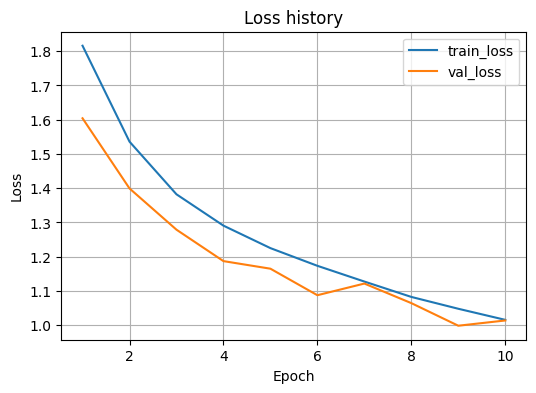

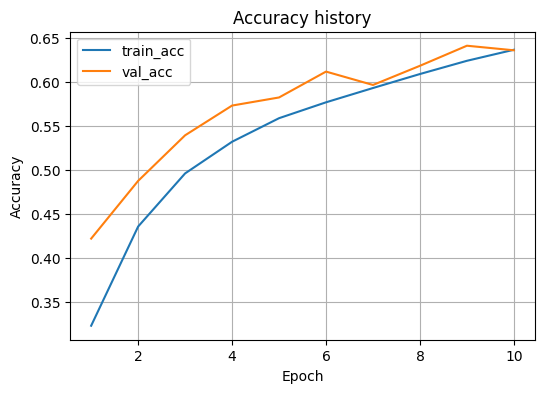

In [22]:
def plot_history(history: Dict[str, List[float]]):
    if not history.get("train_loss"):
        print("History is empty. Train the model first or pass a filled history dictionary.")
        return

    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(6, 4))
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss history")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy history")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_history(history)


# 14. Дополнительное задание: визуализация attention

После forward pass в каждом attention-блоке сохранено поле `last_attention`.

Форма: `[B, heads, N + 1, N + 1]`

Для визуализации можно взять attention из CLS token к patch tokens:

```python
attn[0, head_id, 0, 1:]
```

Затем reshape в сетку `sqrt(N) x sqrt(N)`.


In [23]:
def get_last_block_cls_attention(model: VisionTransformer, x: torch.Tensor, head_id: int = 0) -> torch.Tensor:
    model.eval()
    with torch.no_grad():
        _ = model(x.unsqueeze(0).to(DEVICE))
        
    attn = model.blocks[-1].attn.last_attention[0, head_id]
    
    cls_attn = attn[0, 1:]
    
    grid_size = int(math.sqrt(cls_attn.shape[0]))
    cls_attn_map = cls_attn.reshape(grid_size, grid_size).cpu()
    
    return cls_attn_map

def visualize_attention_on_image(image: torch.Tensor, attention_map: torch.Tensor):
    img = image.permute(1, 2, 0).cpu().numpy()
    
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2470, 0.2435, 0.2616])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    
    attn_tensor = attention_map.unsqueeze(0).unsqueeze(0)
    attn_resized = F.interpolate(attn_tensor, size=(img.shape[0], img.shape[1]), mode='bicubic', align_corners=False)
    attn_resized = attn_resized.squeeze().numpy()
    
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img)
    axes[0].set_title("Original Image")
    axes[0].axis("off")
    
    axes[1].imshow(attn_resized, cmap='jet')
    axes[1].set_title("Attention Map")
    axes[1].axis("off")
    
    axes[2].imshow(img)
    axes[2].imshow(attn_resized, cmap='jet', alpha=0.5)
    axes[2].set_title("Overlay")
    axes[2].axis("off")
    
    plt.show()

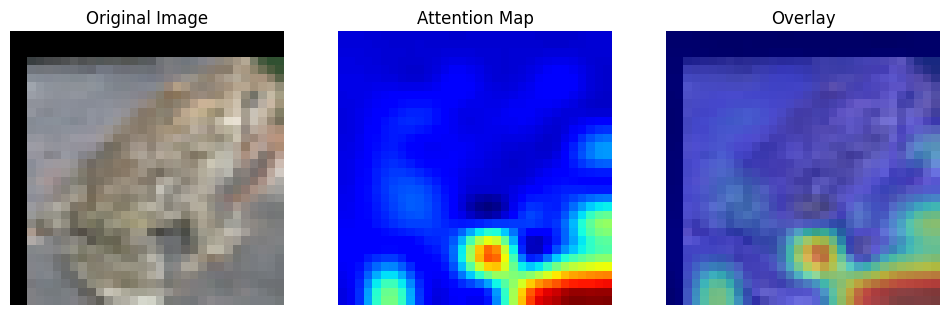

In [24]:
x_batch, y_batch = next(iter(val_loader))

x_sample = x_batch[0]
attn_map = get_last_block_cls_attention(model, x_sample, head_id=0)

visualize_attention_on_image(x_sample, attn_map)

# 16. Вопросы 2

1. Почему сложность self-attention растёт как `O(N^2)` по числу токенов?
2. Почему ViT обычно требует больше данных, чем CNN?
3. Что произойдёт, если убрать residual connections?
4. Что произойдёт, если убрать LayerNorm?


## Ваш ответ:
1) Во время операции self-attention каждый из N токенов должен вычислить свое сходство с каждым из остальных N токенов. В результате создается матрица  размером N * N, что алгоритмически и по памяти дает квадратичную зависимость.
2) В сверточных сетях изначально вшито понимание картинки, они знают, что соседние пиксели сильно связаны (так работают локальные фильтры) и что объект остается объектом, если его сдвинуть. ViT обрабатывает изображение как неструктурированный набор токенов. Трансформеру приходится самому учить эти пространственные правила и концепцию 2D-структуры с нуля, на что требуется большой объем данных.
3) Без residual connections сеть станет подвержена проблеме затухания градиентов. Нижние слои трансформера перестанут нормально обучаться, а сама модель не сможет стать достаточно глубокой без потери информации от оригинальных токенов. Точность упадет.
4) Модель потеряет стабильность обучения. Вектора внутри трансформера очень быстро вырастут или упадут в масштабе из-за большого количества линейных преобразований, что приведет к переполнению значений или обнулению градиентов. LayerNorm нормализует дисперсию и среднее, удерживая сеть в нормальном диапазоне. Без него ViT сойдется крайне сложно или вообще не сойдется.